In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_index=pd.read_csv('economic_index.xls')

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
df_index.tail()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
19,19,2016,5,1.75,6.1,866
20,20,2016,4,1.75,5.9,876
21,21,2016,3,1.75,6.2,822
22,22,2016,2,1.75,6.2,704
23,23,2016,1,1.75,6.1,719


In [5]:
## drop unnecessary column
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [6]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

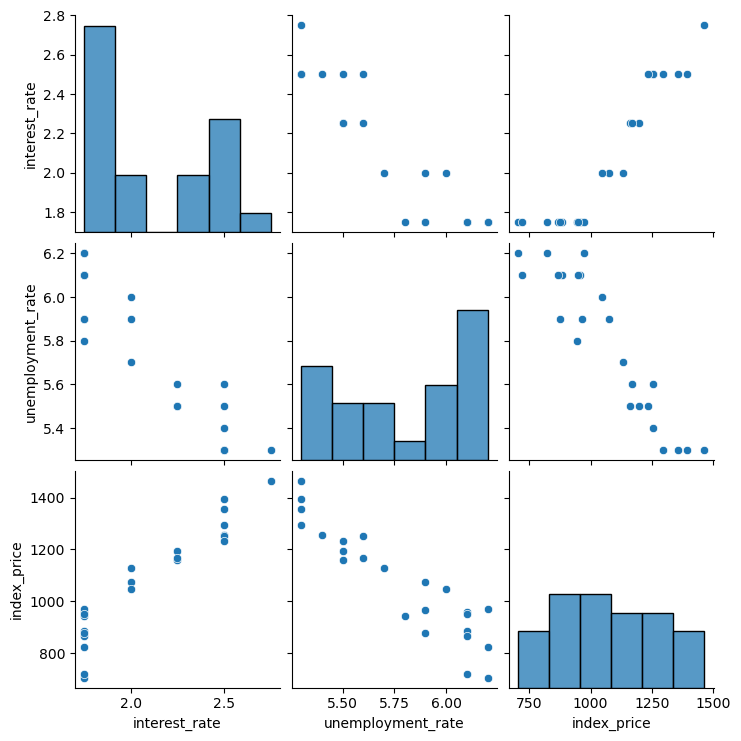

In [8]:
### visualization
import seaborn as sns
sns.pairplot(df_index)
plt.show()

In [9]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


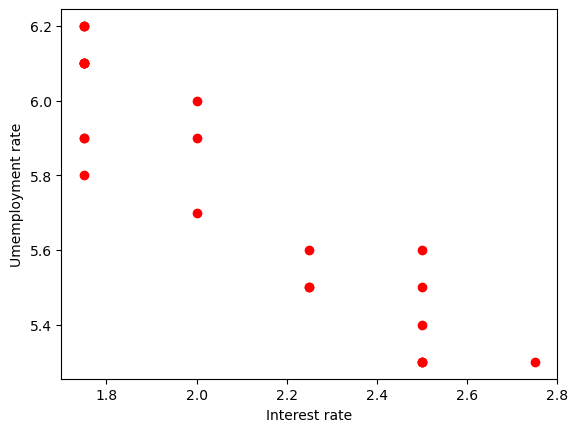

In [10]:
### visulaize more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='red')
plt.xlabel('Interest rate')
plt.ylabel('Umemployment rate')
plt.show()

In [11]:
### independent and dependent features
x=df_index[['interest_rate','unemployment_rate']]
y=df_index[['index_price']]

In [12]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [13]:
y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [14]:
### train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

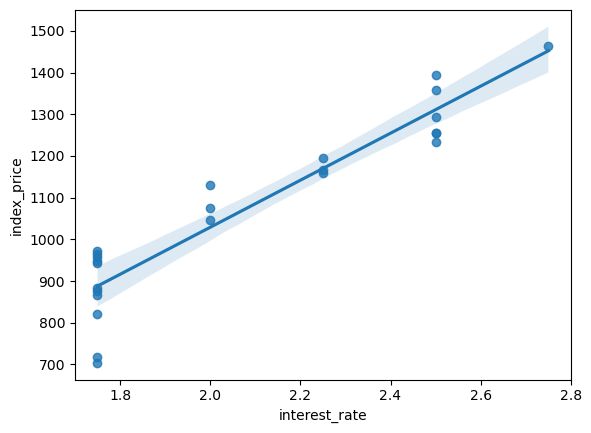

In [15]:
import seaborn as sns
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])
plt.show()


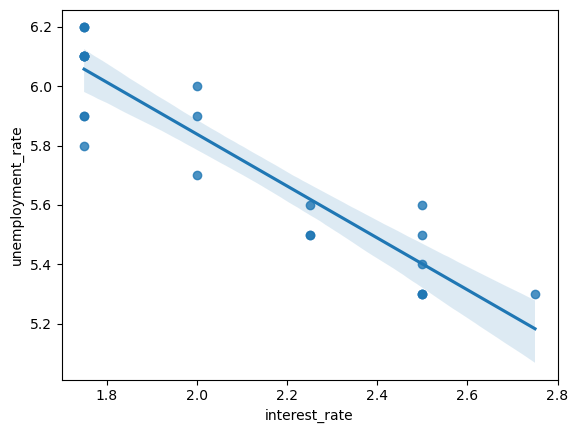

In [16]:
import seaborn as sns
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])
plt.show()


In [17]:
### standardization 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()      
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



In [18]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [19]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [20]:
regression.fit(x_train,y_train)

LinearRegression()

In [21]:
## cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',
                                cv=3)

cv means suppose we have 1000 records and we are using 900 for trainung and 100 for test
then out of 900 train data 900/5 = 180 will be test data and remaining will be train data and 
when cv=3 means we will get 3 values and we have to take their mean 

In [22]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [23]:
np.mean(validation_score)

-5914.828180162388

In [24]:
## prediction
y_pred=regression.predict(x_test)

In [25]:
y_pred

array([[1204.22770398],
       [ 821.65051903],
       [1406.51300368],
       [ 857.70889608],
       [ 994.90992298],
       [1168.16932693]])

In [26]:
### performance matrix
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712579
59.935781523235526
76.11677139574812


In [27]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.8278978091457142


In [28]:
## display adjusted r squared
score = regression.score(x_test, y_test)   # R²

n = len(y_test)          # number of observations
k = x_test.shape[1]      # number of predictors

adjusted_r2 = 1 - (1 - score) * (n - 1) / (n - k - 1)
adjusted_r2

0.713163015242857

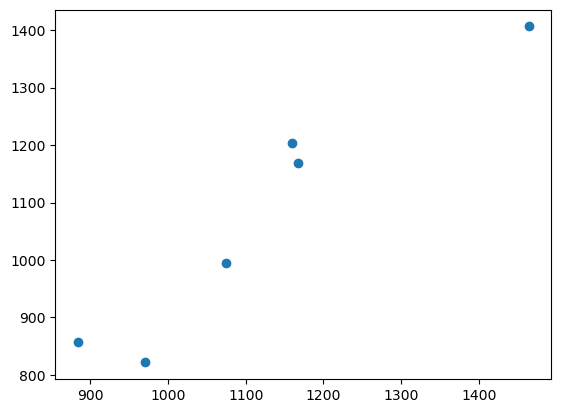

In [29]:
## assumptions
plt.scatter(y_test,y_pred)
plt.show()


In [30]:
residuals=y_test-y_pred
print(residuals)

    index_price
8    -45.227704
16   149.349481
0     57.486996
18    26.291104
11    80.090077
9     -1.169327


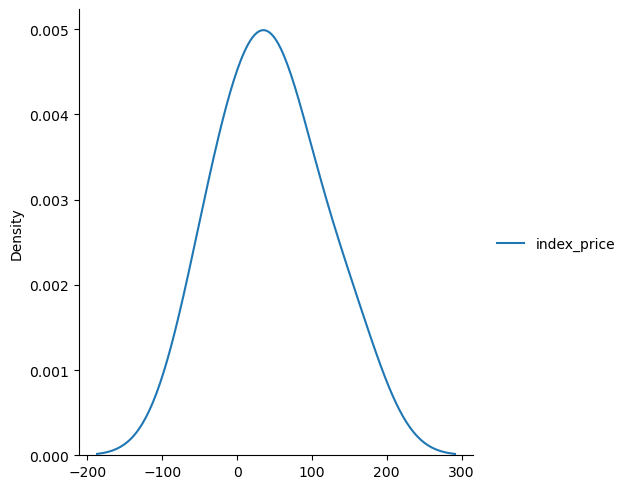

In [31]:
## plotting residuals
sns.displot(residuals,kind='kde')
plt.show()

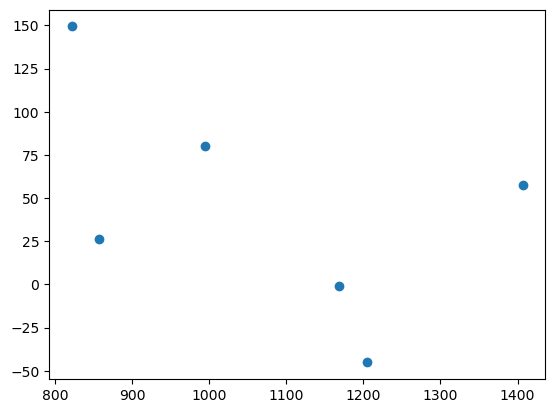

In [32]:
## scatter plot for residuals and predictions
plt.scatter(y_pred,residuals)
plt.show()

In [33]:
### ols technique regression
import statsmodels.api as sm

In [34]:
model=sm.OLS(y_train,x_train).fit()

In [35]:
model.predict(x_test)

array([ 150.78325954, -231.79392541,  353.06855924, -195.73554836,
        -58.53452146,  114.72488249])

In [36]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Tue, 09 Dec 2025   Prob (F-statistic):                       0.754
Time:                        10:26:37   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


In [37]:
print(regression.coef_)

[[  88.27275507 -116.25716066]]
